In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)        # rows and columns
print(df.dtypes)       # column data types
print(df.isnull().sum()) # missing values

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

In [4]:
df['Churn'].value_counts() 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())  # we are trying to get the null values
# so those null value are brand new customers with zero tenure. so we will Drop them

11


In [7]:
df = df.dropna(subset=['TotalCharges']) #Dropping the rows where value is nan or null as brand new customers
print(df.shape) #getting latest count for row and col

(7032, 21)


In [8]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn['Yes'] = (contract_churn['Yes'] * 100).round(1)
print(contract_churn[['Yes']].rename(columns={'Yes': 'Churn Rate %'}))

Churn           Churn Rate %
Contract                    
Month-to-month          42.7
One year                11.3
Two year                 2.8


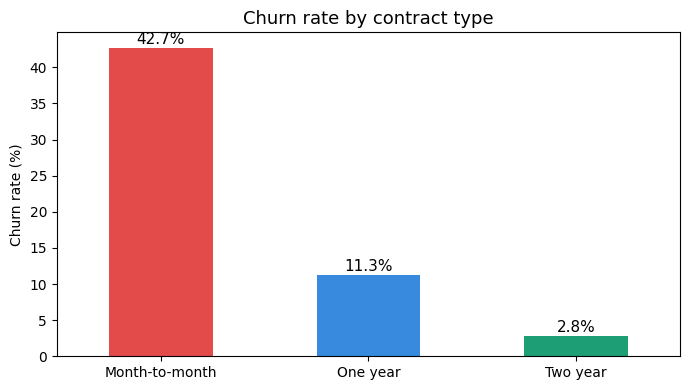

In [9]:
ax = contract_churn['Yes'].plot(kind='bar', color=['#E24B4A','#378ADD','#1D9E75'], 
                                 figsize=(7,4), edgecolor='none')
ax.set_title('Churn rate by contract type', fontsize=13)
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5), 
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# This graph shows below insights :
# 1. Month-to-month customers churn at 15x the rate of two-year contract customers
# 2. This tells the business: "locking customers into longer contracts is the single biggest retention lever"

In [11]:
df['tenure_bucket'] = pd.cut(df['tenure'], 
                              bins=[0, 6, 12, 24, 48, 72], 
                              labels=['0–6 mo', '7–12 mo', '13–24 mo', '25–48 mo', '49–72 mo'])

tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].value_counts(normalize=True).unstack()
tenure_churn['Yes'] = (tenure_churn['Yes'] * 100).round(1)
print(tenure_churn[['Yes']].rename(columns={'Yes': 'Churn Rate %'}))

Churn          Churn Rate %
tenure_bucket              
0–6 mo                 53.3
7–12 mo                35.9
13–24 mo               28.7
25–48 mo               20.4
49–72 mo                9.5


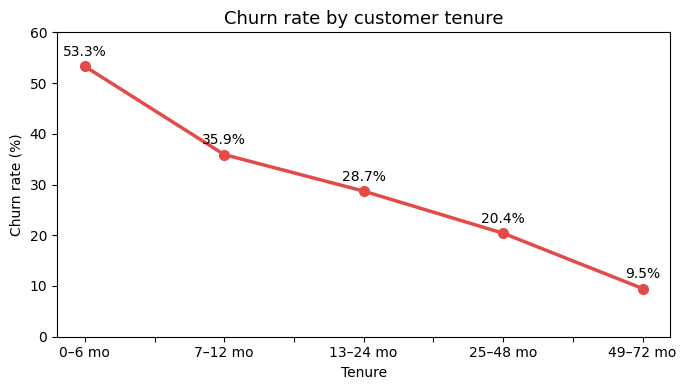

In [12]:
ax = tenure_churn['Yes'].plot(kind='line', marker='o', color='#E24B4A',
                               figsize=(7, 4), linewidth=2.5, markersize=7)
ax.set_title('Churn rate by customer tenure', fontsize=13)
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('Tenure')
ax.set_ylim(0, 60)
for x, y in enumerate(tenure_churn['Yes']):
    ax.annotate(f"{y}%", (x, y + 2), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# Churn by Tenure gives us following insights : 
# 1. The first 6 months are the highest risk window — nearly 1 in 2 new customers churn
# 2. Risk drops sharply after 2 years — loyal customers tend to stay
# 3. This means retention efforts should focus on onboarding and the first 6 months, not on long-tenure customers.


In [14]:
df['charge_bucket'] = pd.cut(df['MonthlyCharges'],
                              bins=[0, 30, 50, 70, 90, 120],
                              labels=['< $30', '$30–50', '$50–70', '$70–90', '> $90'])

charge_churn = df.groupby('charge_bucket', observed=True)['Churn'].value_counts(normalize=True).unstack()
charge_churn['Yes'] = (charge_churn['Yes'] * 100).round(1)
print(charge_churn[['Yes']].rename(columns={'Yes': 'Churn Rate %'}))

Churn          Churn Rate %
charge_bucket              
< $30                   9.8
$30–50                 30.8
$50–70                 20.8
$70–90                 37.8
> $90                  32.8


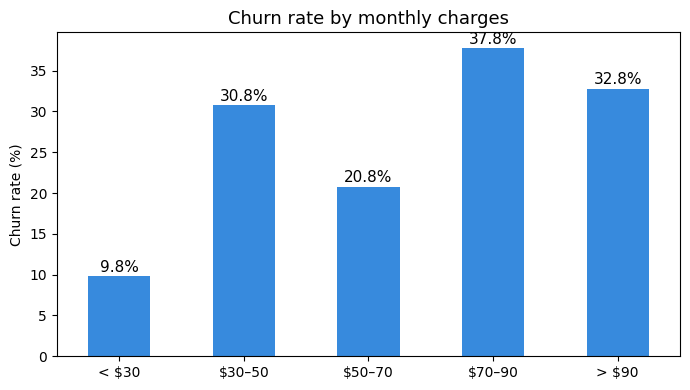

In [15]:
ax = charge_churn['Yes'].plot(kind='bar', color='#378ADD',
                               figsize=(7, 4), edgecolor='none')
ax.set_title('Churn rate by monthly charges', fontsize=13)
ax.set_ylabel('Churn rate (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
risky = df[df['charge_bucket'] == '$70–90']
print(risky['Contract'].value_counts(normalize=True).mul(100).round(1))

Contract
Month-to-month    67.4
Two year          17.9
One year          14.7
Name: proportion, dtype: float64


In [18]:
print("=== KEY FINDINGS ===")
print(f"1. Overall churn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"2. Month-to-month churn rate: 42.7%")
print(f"3. New customer churn (0-6 mo): 53.3%")
print(f"4. Highest charge-bracket churn ($70-90): 37.8%")

=== KEY FINDINGS ===
1. Overall churn rate: 26.6%
2. Month-to-month churn rate: 42.7%
3. New customer churn (0-6 mo): 53.3%
4. Highest charge-bracket churn ($70-90): 37.8%
